# Business Impact — Conversion Rate by Market Position Score

This notebook answers the key business question: **does a better market
position score translate into more policies sold?**

The scoring represents where our price sits in the predicted competitor
price distribution:
- **High score (close to 1)** → we are cheaper than most competitors
- **Low score (close to 0)** → we are more expensive than most competitors

If the model is correctly capturing market dynamics, quotes with a higher
score should convert to policies at a higher rate — because customers who
shop around will find our price competitive.

We also compare conversion across three model versions to show how improved
pricing calibration translates into measurable uplift.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *

pd.set_option('display.max_columns', 100)

## 1. Load Data

In [2]:
df = pd.read_csv('../data/results_data.csv')

print(f"Quotes: {len(df):,}")
print(f"Overall conversion rate: {df['converted'].mean():.2%}")
print("\nConversion by model version:")
print(df.groupby('model_version')['converted'].agg(['mean', 'count']).round(3))

Quotes: 1,000
Overall conversion rate: 17.80%

Conversion by model version:
                mean  count
model_version              
1              0.151    312
2              0.189    349
3              0.192    339


## 2. Conversion Rate by Scoring Bucket

Bin the scoring into deciles and plot average conversion per bin.
A monotonically increasing curve confirms that the model's score is a
reliable proxy for competitive advantage.

scoring_decile  conversion  n_quotes
         0-10%    0.000000        21
        10-20%    0.125828       151
        30-40%    0.203175       315
        50-60%    0.170213       329
        70-80%    0.187500       144
       90-100%    0.300000        40


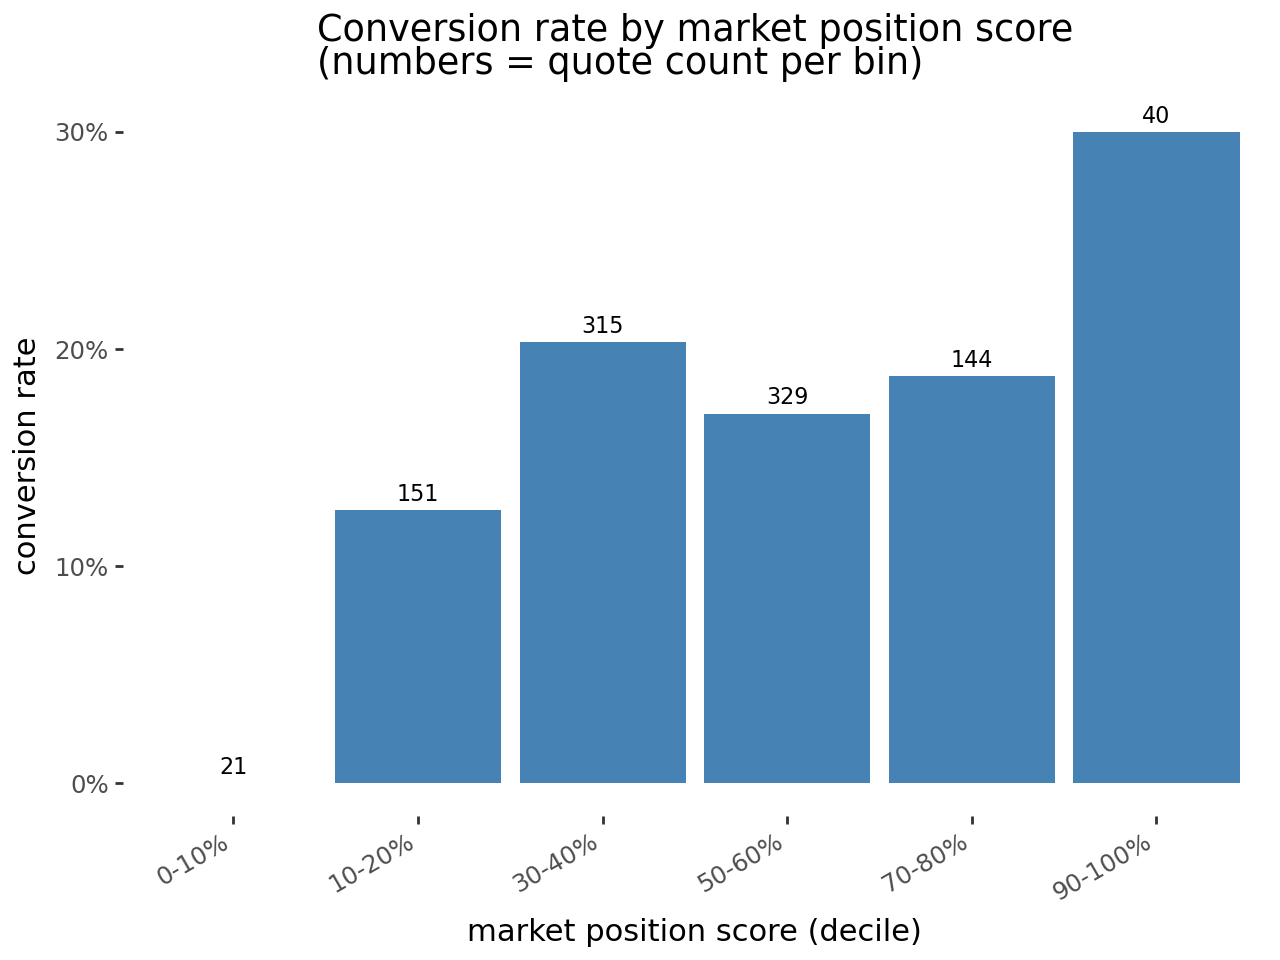

In [3]:
df['scoring_decile'] = pd.cut(
    df['scoring'], bins=10, labels=[f'{i*10}-{(i+1)*10}%' for i in range(10)]
)

conv_by_decile = (
    df.groupby('scoring_decile', observed=True)
    .agg(conversion=('converted', 'mean'), n_quotes=('converted', 'count'))
    .reset_index()
)
print(conv_by_decile.to_string(index=False))

(ggplot(conv_by_decile, aes(x='scoring_decile', y='conversion'))
 + geom_col(fill='steelblue')
 + geom_text(aes(label='n_quotes'), va='bottom', size=8, nudge_y=0.002)
 + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank(),
         axis_text_x=element_text(angle=30, ha='right'))
 + labs(x='market position score (decile)',
        y='conversion rate',
        title='Conversion rate by market position score\n(numbers = quote count per bin)')
)

## 3. Model Version Comparison

Three pricing model versions were deployed over time. Later versions produce
better-calibrated scores, which lead to higher conversion at the same price
point. The line chart below shows conversion as a function of scoring — a
higher line at any given score means the model is extracting more business
value from the same level of market competitiveness.

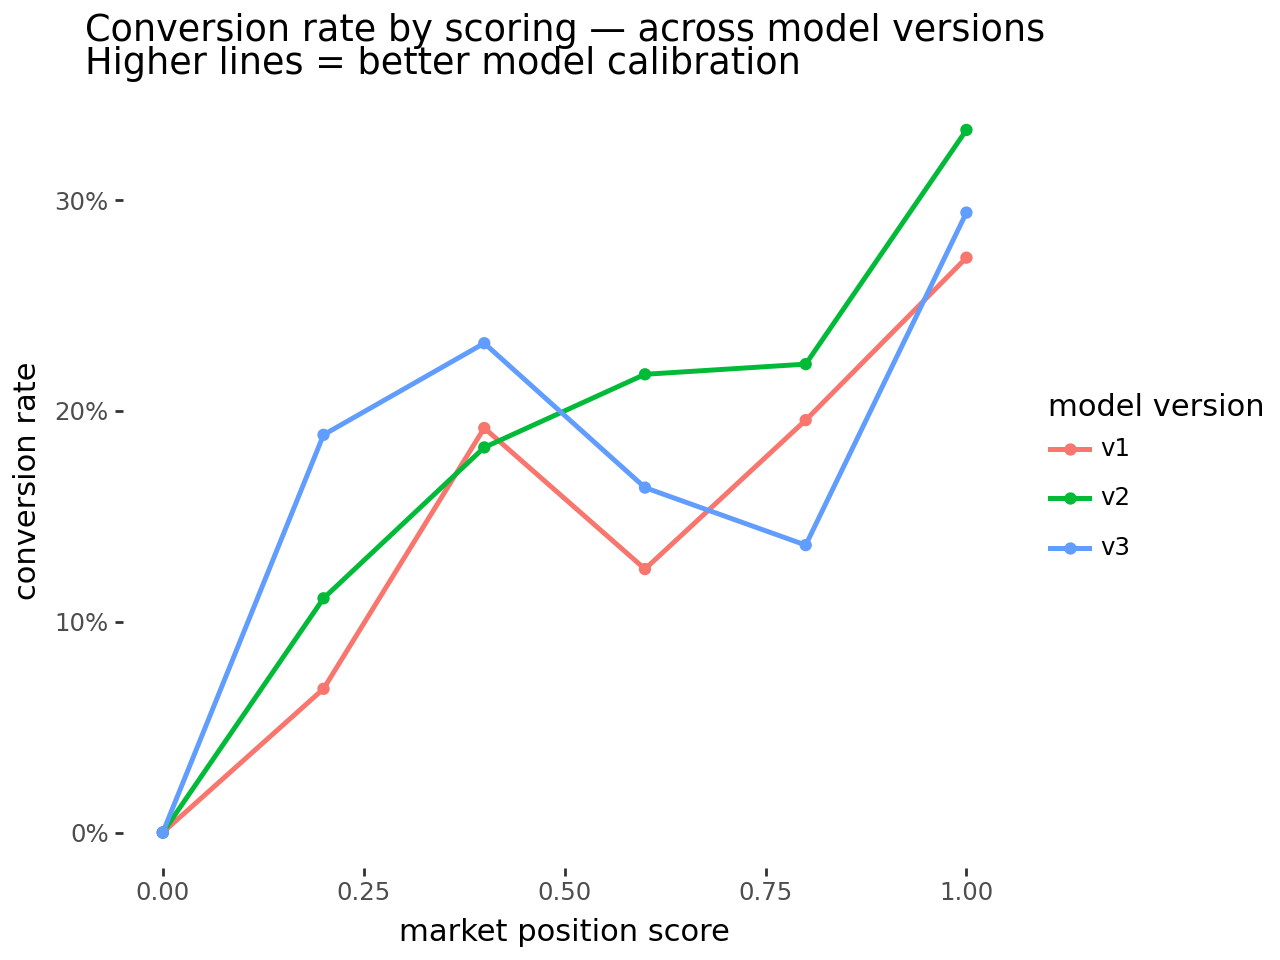

In [4]:
df['scoring_bin'] = pd.cut(df['scoring'], bins=20, labels=False)

conv_by_version = (
    df.groupby(['model_version', 'scoring_bin'], observed=True)
    .agg(
        conversion=('converted', 'mean'),
        n_quotes=('converted', 'count'),
        scoring_mid=('scoring', 'mean'),
    )
    .reset_index()
)
conv_by_version['model_version'] = 'v' + conv_by_version['model_version'].astype(str)

(ggplot(conv_by_version, aes(x='scoring_mid', y='conversion', color='model_version'))
 + geom_line(size=1)
 + geom_point(size=1.5)
 + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank())
 + labs(x='market position score', y='conversion rate', color='model version',
        title='Conversion rate by scoring — across model versions\nHigher lines = better model calibration')
)

## 4. Aggregate Conversion Uplift

Summarise the total conversion improvement from v1 → v3.

In [5]:
uplift = (
    df.groupby('model_version')
    .agg(
        n_quotes=('converted', 'count'),
        n_converted=('converted', 'sum'),
        conversion_rate=('converted', 'mean'),
    )
    .reset_index()
)
uplift['conversion_rate'] = uplift['conversion_rate'].map('{:.2%}'.format)
print(uplift.to_string(index=False))

v1 = df[df['model_version'] == 1]['converted'].mean()
v3 = df[df['model_version'] == 3]['converted'].mean()
print(f"\nRelative uplift v1 → v3: {(v3 - v1) / v1:+.1%}")

 model_version  n_quotes  n_converted conversion_rate
             1       312           47          15.06%
             2       349           66          18.91%
             3       339           65          19.17%

Relative uplift v1 → v3: +27.3%
